In [1]:
# 
library(data.table)

In [5]:
# get files
setwd('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/')
files = sort(list.files('derived/tmp/', full.names = TRUE))
print(head(files))

[1] "derived/tmp//ukb_wes_200k_phased_all_maf002_nofilter_test_chr22_burden.tsv.gz" 
[2] "derived/tmp//ukb_wes_200k_phased_all_maf002_nofilter_test_chr22_ko_prob.tsv.gz"


In [6]:
d1 <- fread("derived/tmp//ukb_wes_200k_phased_all_maf002_nofilter_test_chr22_burden.tsv.gz")
d2 <- fread("derived/tmp//ukb_wes_200k_phased_all_maf002_nofilter_test_chr22_ko_prob.tsv.gz")

In [4]:
dt <- do.call(rbind, lapply(files, function(f){
    d = fread(f)
    name = basename(f)
    chr = unlist(lapply(strsplit(name, split = '_'), function(x) x[7]))
    d$chr = chr
    return(d)
}))



In [12]:
colnames(d1)
d1[d1$n>0,]

[1] "Gene"                 "consequence_category" "s"                   
[4] "n"                    "singletons"           "total"

Gene,consequence_category,s,n,singletons,total
<chr>,<chr>,<int>,<int>,<int>,<int>
,non_coding,1010963,1,0,1
,non_coding,1016162,1,0,1
,non_coding,1036900,1,0,1
,non_coding,1051342,1,0,1
,non_coding,1054362,1,0,1
,non_coding,1059455,1,0,1
,non_coding,1084796,1,0,1
,non_coding,1097669,1,0,1
,non_coding,1099323,1,0,1


In [50]:
length(samples)/190000 # looks like 4.3% of individuals are knockouts.. but there does not look like there any any singletons?

[1] 0.04307895

In [51]:
# get files
files = sort(list.files('../derived/knockouts/eur/missense_and_ptv/', full.names = TRUE, pattern = 'burden'))

In [56]:
# all singletons have been removed?
dt <- fread(files[21])
sum(dt$singletons > 0)

[1] 0

[1] 0

In [19]:
x = as.data.table(table(d$s, d$consequence_category))

V1,V2,N
<chr>,<chr>,<int>
1000028,damaging_missense,1
1000034,damaging_missense,1
1000087,damaging_missense,3
1000118,damaging_missense,1
1000120,damaging_missense,1
1000162,damaging_missense,1


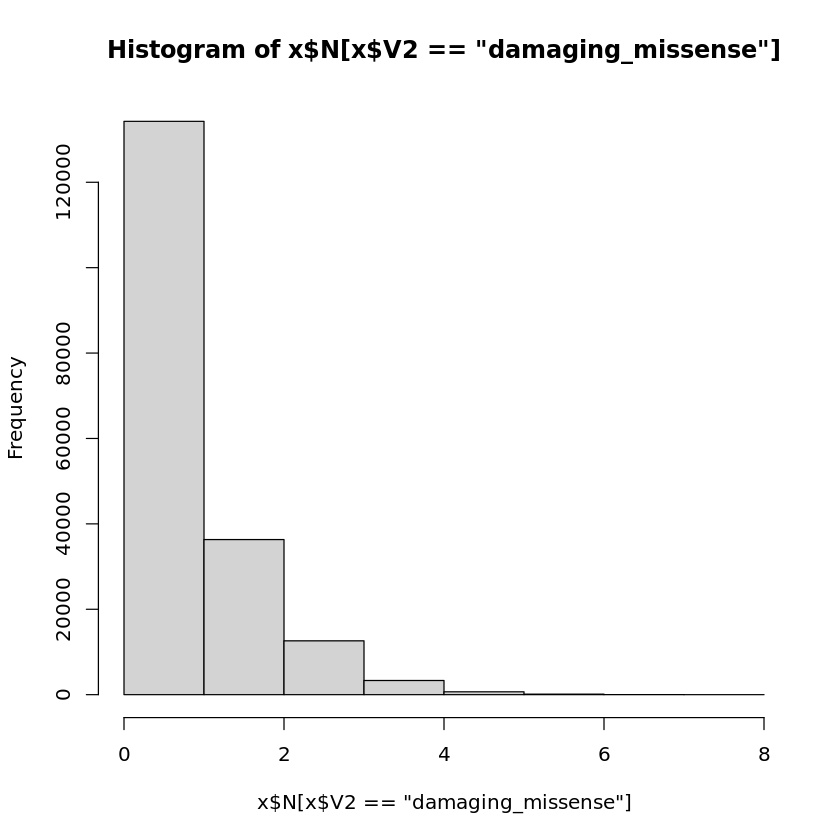

In [28]:
hist(x$N[x$V2=='damaging_missense'], breaks = 10)